# Statistical arbitrage on the Euro Stoxx 50

A walkthrough of Avellaneda & Lee (2008), PCA strand.

This notebook opens up **one** rebalance date to show what the model sees, then
runs the full walk-forward backtest. Every table and figure in the README comes
from `scripts/run_experiments.py`; nothing is computed twice.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))

from statarb.config import StrategyConfig
from statarb.data import (
    compute_returns,
    coverage_report,
    load_prices,
    load_ticker_details,
    prepare_estimation_window,
)
from statarb.factor_model import extract_factors, fit_factor_regression
from statarb.metrics import performance_statistics
from statarb.ou import estimate_ou_parameters, false_positive_rate
from statarb.signals import compute_s_scores
from statarb.strategy import run_strategy

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

DATA = Path.cwd().parent / "data"
config = StrategyConfig(no_trade_band=0.005)
config

StrategyConfig(estimation_window=252, ou_window=60, min_coverage=0.95, n_factors=4, target_variance=None, min_mean_reversion_speed=8.4, max_ar1_coefficient=0.9672, bias_correction=False, center_ou_means=True, use_modified_s_score=False, s_open_long=1.25, s_open_short=1.25, s_close_long=0.5, s_close_short=0.75, hedge_factor_exposure=True, weighting='fixed_notional', notional_per_position=0.05, execution_lag=1, transaction_costs=0.0005, no_trade_band=0.005, trading_time=False, volume_window=60, max_volume_adjustment=10.0)

## 1. Data

Total-return index levels in EUR, forward-filled across local market holidays.

In [2]:
prices = load_prices(DATA / "sx5e_underlyings.csv")
returns = compute_returns(prices)
sectors = load_ticker_details(DATA / "ticker_details.csv")["GICS"]

print(f"{prices.shape[1]} names, {prices.index[0].date()} to {prices.index[-1].date()}")
coverage_report(prices, returns).head(8).round(4)

50 names, 2013-01-02 to 2023-02-17


/tmp/ipykernel_137/3503292213.py:6: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  coverage_report(prices, returns).head(8).round(4)


,first_observation,missing_returns,zero_return_share,annualised_volatility
ABI.BR,2013-01-02,0,0.0108,0.2763
INGA.AS,2013-01-02,0,0.0096,0.3384
ISP.MI,2013-01-02,0,0.0235,0.3410
ITX.MC,2013-01-02,0,0.0162,0.2605
LVMH.PA,2013-01-02,0,0.0112,0.2643
MBGn.DE,2013-01-02,0,0.0150,0.3151
MUVGn.DE,2013-01-02,0,0.0227,0.2387
NDAFI.HE,2013-01-02,0,0.0358,0.2655


The three names at the top joined the index mid-sample, so they carry long
leading gaps; the coverage filter keeps them out of the estimation window until
they have enough history. The `zero_return_share` column measures how much the
forward fill contributes: a few percent for names whose local exchange closes on
days the rest of Europe trades.

## 2. One rebalance date

### 2.1 PCA on the correlation matrix

2022-02-28 to 2023-02-17  -> (252, 50)


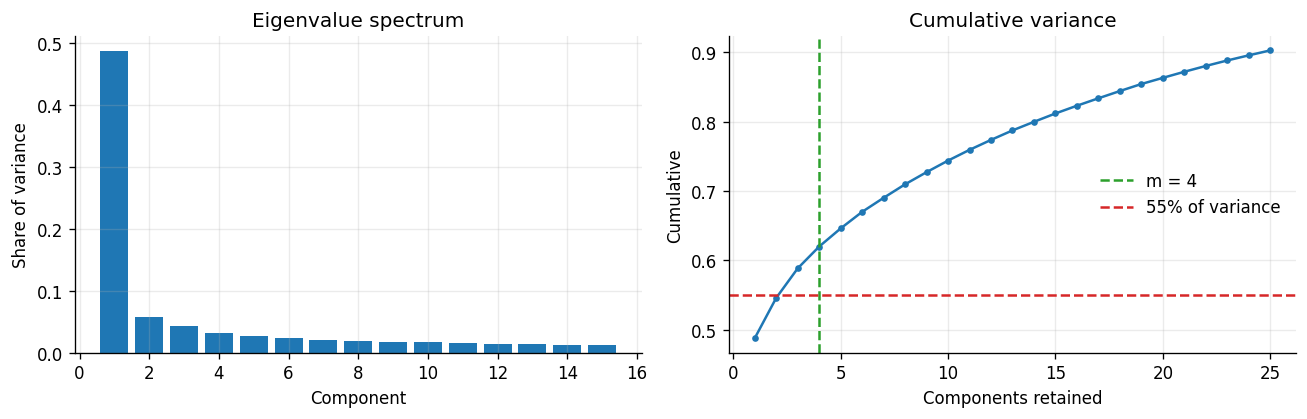

first component alone: 48.7%
m = 4: 62.0%


In [3]:
rebalance_date = returns.index[-1]
window, diagnostics = prepare_estimation_window(
    returns, rebalance_date, config.estimation_window, config.min_coverage
)
print(f"{window.index[0].date()} to {window.index[-1].date()}  -> {window.shape}")

decomposition = extract_factors(window, n_factors=config.n_factors)

shares = decomposition.metadata["explained_variance_per_component"]
cumulative = decomposition.metadata["cumulative_explained_variance"]

figure, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].bar(range(1, 16), shares[:15], color="tab:blue")
axes[0].set(xlabel="Component", ylabel="Share of variance", title="Eigenvalue spectrum")
axes[1].plot(range(1, 26), cumulative[:25], "o-", markersize=3)
axes[1].axvline(config.n_factors, color="tab:green", ls="--", label=f"m = {config.n_factors}")
axes[1].axhline(0.55, color="tab:red", ls="--", label="55% of variance")
axes[1].set(xlabel="Components retained", ylabel="Cumulative", title="Cumulative variance")
axes[1].legend(frameon=False)
plt.tight_layout(); plt.show()

print(f"first component alone: {shares[0]:.1%}")
print(f"m = {config.n_factors}: {decomposition.total_explained_variance:.1%}")

### 2.2 The factors are eigenportfolios

Equation (9) sets the dollar holdings of portfolio *j* to `Q_i = v_i / σ_i`, so a
factor return is a portfolio return. Two properties follow, and both are worth
checking rather than assuming.

In [4]:
correlation = decomposition.factors.corr().to_numpy()
print(f"max |corr(F_j, F_k)|, j != k : {np.abs(correlation - np.eye(config.n_factors)).max():.2e}")

first = decomposition.eigenportfolios["PC1"]
print(f"PC1 weights positive          : {(first > 0).sum()}/{len(first)}")
print(f"corr(Q1, 1/sigma)             : {np.corrcoef(first, 1 / decomposition.volatilities)[0, 1]:.2f}")

max |corr(F_j, F_k)|, j != k : 4.32e-16
PC1 weights positive          : 50/50
corr(Q1, 1/sigma)             : 0.53


The factors are orthogonal to machine precision. That is not luck: with
`D = diag(σ)` and `Σ = D ρ D`, the covariance of two eigenportfolio returns is
`(v_j/σ)' Σ (v_k/σ) = v_j' ρ v_k = λ_j δ_jk`. The design matrix of the factor
regression is orthogonal by construction, so the loadings do not move when a
component is added — which is exactly what ETF-based factors cannot offer, since
sector ETFs are correlated with one another.

The first eigenportfolio is long every name with weights inversely proportional
to volatility: the market mode.

### 2.3 Sector coherence of the higher components

The paper's section 2.2 claims that, once sorted, neighbouring coefficients of
the second and third eigenvectors belong to the same industry. On 50 European
names it reads more cleanly than on the 1400 US names of the paper.

In [5]:
for component in ["PC2", "PC3"]:
    loadings = decomposition.eigenvectors[component].sort_values(ascending=False)
    top = pd.DataFrame({"loading": loadings.head(5).round(3),
                        "sector": sectors.reindex(loadings.head(5).index)})
    bottom = pd.DataFrame({"loading": loadings.tail(5).round(3),
                           "sector": sectors.reindex(loadings.tail(5).index)})
    print(f"\n=== {component} ===")
    print(top.to_string())
    print("   ...")
    print(bottom.to_string())


=== PC2 ===
          loading                  sector
HRMS.PA     0.275  Consumer Discretionary
OREP.PA     0.253        Consumer Staples
ADYEN.AS    0.233              Financials
SAPG.DE     0.186  Information Technology
LVMH.PA     0.186  Consumer Discretionary
   ...
          loading       sector
MUVGn.DE   -0.189   Financials
INGA.AS    -0.189   Financials
SASY.PA    -0.203  Health Care
ENI.MI     -0.213       Energy
TTEF.PA    -0.256       Energy

=== PC3 ===
          loading                  sector
DANO.PA     0.318        Consumer Staples
AD.AS       0.304        Consumer Staples
SASY.PA     0.303             Health Care
IBE.MC      0.285               Utilities
DTEGn.DE    0.255  Communication Services
   ...
           loading                  sector
IFXGn.DE    -0.158  Information Technology
VOWG_p.DE   -0.171  Consumer Discretionary
MBGn.DE     -0.192  Consumer Discretionary
BMWG.DE     -0.205  Consumer Discretionary
PRX.AS      -0.213  Consumer Discretionary


### 2.4 Residuals and the Ornstein–Uhlenbeck fit

Loadings come from the last 60 days, factors from the full 252-day window. The
cumulative residual `X_k = Σ ε_j` is the auxiliary process the appendix fits.

In [6]:
regression_window = window.loc[:, decomposition.eigenportfolios.index].iloc[-config.ou_window:]
regression = fit_factor_regression(
    regression_window, decomposition.factors.iloc[-config.ou_window:]
)
levels = regression.cumulative_residuals

print(f"mean R^2 across names : {regression.r_squared.mean():.1%}")
print(f"max |X_T|             : {np.abs(levels.iloc[-1]).max():.2e}   <- forced to zero by the regression")

parameters = estimate_ou_parameters(
    levels, dt=config.dt,
    min_mean_reversion_speed=config.min_mean_reversion_speed,
    max_ar1_coefficient=config.max_ar1_coefficient,
    center_means=config.center_ou_means,
)
parameters.loc[parameters["is_tradeable"], ["b", "kappa", "m", "sigma_eq", "half_life_days"]].head(8).round(4)

mean R^2 across names : 55.8%
max |X_T|             : 8.62e-14   <- forced to zero by the regression


,b,kappa,m,sigma_eq,half_life_days
ABI.BR,0.9579,10.8507,0.0364,0.0239,16.0979
AD.AS,0.8429,43.0823,-0.0160,0.0182,4.0544
ADSGn.DE,0.9622,9.7178,0.0641,0.0573,17.9745
ADYEN.AS,0.8349,45.4865,-0.0508,0.0430,3.8401
AIR.PA,0.9101,23.7462,-0.0199,0.0320,7.3558
AIRP.PA,0.7837,61.4333,-0.0117,0.0115,2.8433
ALVG.DE,0.9333,17.3940,0.0209,0.0148,10.0422
ASML.AS,0.8520,40.3722,0.0061,0.0204,4.3266


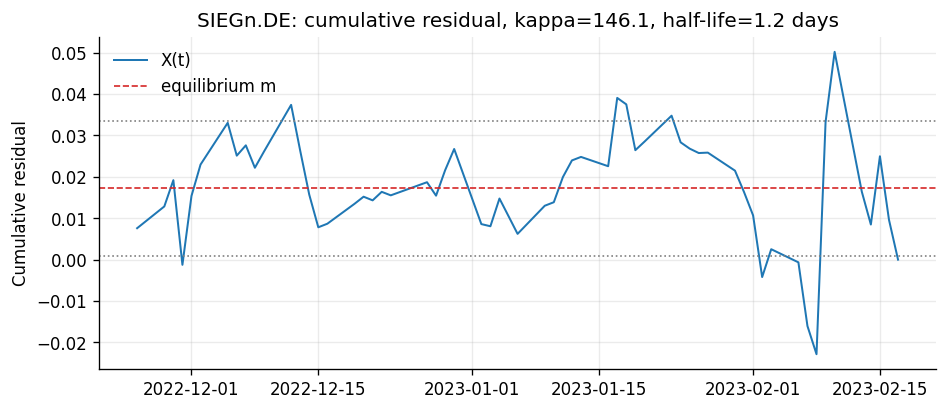

In [7]:
asset = parameters.loc[parameters["is_tradeable"], "kappa"].idxmax()
row = parameters.loc[asset]

figure, axis = plt.subplots(figsize=(9, 3.6))
axis.plot(levels.index, levels[asset], color="tab:blue", lw=1.2, label="X(t)")
axis.axhline(row["m"], color="tab:red", ls="--", lw=1, label="equilibrium m")
for sign in (-1, 1):
    axis.axhline(row["m"] + sign * 1.25 * row["sigma_eq"], color="grey", ls=":", lw=1)
axis.set(title=f"{asset}: cumulative residual, kappa={row['kappa']:.1f}, "
               f"half-life={row['half_life_days']:.1f} days",
         ylabel="Cumulative residual")
axis.legend(frameon=False); plt.show()

The dotted lines are the ±1.25 σ_eq entry bands. Because the regression forces
`X_T = 0`, today's s-score reduces to `s = −m / σ_eq`, equation (22).

### 2.5 The cross-section of s-scores today

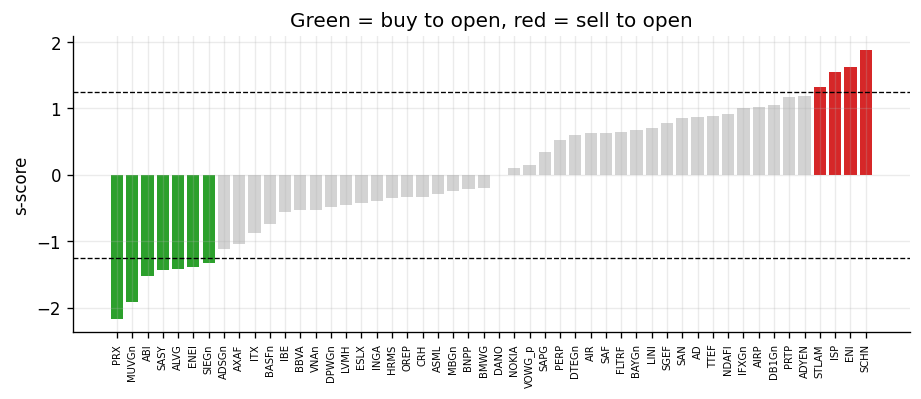

tradeable after the kappa filter : 50/50
long signals  : 7
short signals : 4


In [8]:
scores = compute_s_scores(levels, parameters, regression.alphas,
                          modified=config.use_modified_s_score).dropna().sort_values()

figure, axis = plt.subplots(figsize=(9, 3.2))
colours = ["tab:green" if s < -config.s_open_long else
           "tab:red" if s > config.s_open_short else "lightgrey" for s in scores]
axis.bar(range(len(scores)), scores.values, color=colours)
for level in (-config.s_open_long, config.s_open_short):
    axis.axhline(level, color="black", ls="--", lw=0.8)
axis.set(xticks=range(len(scores)),
         xticklabels=[t.split(".")[0] for t in scores.index],
         ylabel="s-score", title="Green = buy to open, red = sell to open")
axis.tick_params(axis="x", rotation=90, labelsize=6)
plt.show()

print(f"tradeable after the kappa filter : {int(parameters['is_tradeable'].sum())}/{len(parameters)}")
print(f"long signals  : {(scores < -config.s_open_long).sum()}")
print(f"short signals : {(scores > config.s_open_short).sum()}")

### 2.6 How much does the κ filter actually reject?

Almost every name passes it, which is suspicious. Simulating pure random walks —
for which κ = 0, so none should ever qualify — shows why.

In [9]:
rates = pd.DataFrame(
    {"raw": {n: false_positive_rate(n, n_paths=1500) for n in [60, 120, 252, 504]},
     "Kendall-corrected": {n: false_positive_rate(n, n_paths=1500, bias_correction=True)
                           for n in [60, 120, 252, 504]}}
)
rates.index.name = "window length"
(rates * 100).round(1)

,raw,Kendall-corrected
window length,,
60,77.4,34.7
120,53.5,22.8
252,22.0,7.7
504,2.5,1.1


On the paper's 60-day window, roughly three quarters of random walks look like
week-long mean-reverters. OLS on a near-unit-root AR(1) is biased towards zero by
about `(1 + 3b) / T`, which is ~0.07 here.

Correcting the bias, however, collapses the gross Sharpe from 0.91 to 0.15 (see
the design table in the README). The signal is not really a bet on stationarity:
`s = −m/σ_eq` is a normalised short-term reversal measure, and repairing the
estimator removes the very distortion it was exploiting.

## 3. Full walk-forward backtest

In [10]:
%%time
hedged = run_strategy(returns, config)
unhedged = run_strategy(returns, config.variant(hedge_factor_exposure=False))

CPU times: user 1min 7s, sys: 64.1 ms, total: 1min 7s
Wall time: 1min 8s


In [11]:
comparison = pd.DataFrame({
    "hedged": hedged.statistics,
    "unhedged": unhedged.statistics,
}).loc[["annualised_return", "annualised_volatility", "sharpe_ratio", "max_drawdown",
        "hit_rate", "annualised_turnover", "average_gross_exposure"]]

gross = pd.Series({
    "hedged": performance_statistics(hedged.backtest.gross_returns)["sharpe_ratio"],
    "unhedged": performance_statistics(unhedged.backtest.gross_returns)["sharpe_ratio"],
}, name="gross_sharpe")

pd.concat([gross.to_frame().T, comparison]).round(3)

,hedged,unhedged
gross_sharpe,0.910,0.870
annualised_return,0.008,0.024
annualised_volatility,0.045,0.055
sharpe_ratio,0.197,0.464
max_drawdown,-0.104,-0.106
hit_rate,0.494,0.514
annualised_turnover,63.709,44.766
average_gross_exposure,0.982,0.831


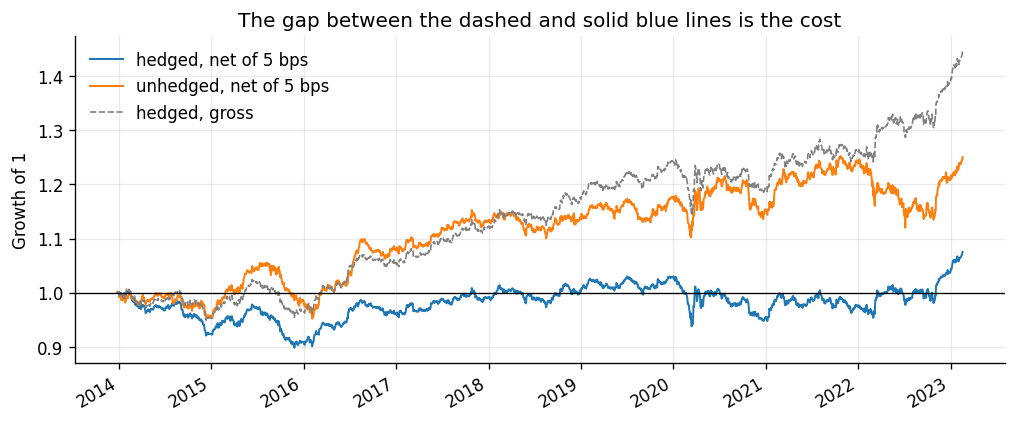

In [12]:
figure, axis = plt.subplots(figsize=(10, 4))
hedged.backtest.net_equity.plot(ax=axis, lw=1.2, label="hedged, net of 5 bps")
unhedged.backtest.net_equity.plot(ax=axis, lw=1.2, label="unhedged, net of 5 bps")
hedged.backtest.gross_equity.plot(ax=axis, lw=1, ls="--", color="grey", label="hedged, gross")
axis.axhline(1.0, color="black", lw=0.8)
axis.set(ylabel="Growth of 1", title="The gap between the dashed and solid blue lines is the cost")
axis.legend(frameon=False); plt.show()

The hedge works exactly as advertised and still loses on a net basis: the
eigenportfolios are re-estimated daily, so the hedge basket churns even when no
signal changed, pushing turnover from 45 to 77 times a year.

In [13]:
print("max residual factor exposure after hedging:",
      hedged.diagnostics["factor_exposure_after_hedge"].max())
print("mean factor exposure before hedging       :",
      hedged.diagnostics["factor_exposure_before_hedge"].mean().round(3))

hedged.diagnostics[["universe_size", "n_tradeable", "n_long", "n_short",
                    "explained_variance", "median_half_life_days",
                    "gross_exposure"]].describe().loc[["mean", "min", "50%", "max"]].round(3)

max residual factor exposure after hedging: 3.13768108717305e-15
mean factor exposure before hedging       : 0.224


,universe_size,n_tradeable,n_long,n_short,explained_variance,median_half_life_days,gross_exposure
mean,48.103,47.637,9.076,7.544,0.596,5.236,0.981
min,46.000,43.000,2.000,1.000,0.460,3.428,0.293
50%,47.000,47.000,9.000,8.000,0.592,5.211,0.991
max,50.000,50.000,18.000,15.000,0.730,7.729,1.678


## 4. Everything else

The remaining studies — entry thresholds, fixed versus variable factor counts,
cost sensitivity, trading time — take a few minutes each and are produced by:

```bash
python scripts/run_experiments.py
python scripts/make_figures.py
```

Their tables land in `results/` and are discussed in the README.